Импортируются стандартные библиотеки для обработки данных, визуализации и машинного обучения. Отдельно загружаются lightgbm (основная модель), IsolationForest (для сравнения). Библиотеки datetime и tqdm понадобятся для работы с временными признаками и отображения прогресса.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score
import lightgbm as lgb
from sklearn.ensemble import IsolationForest

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

#Загрузка и предобработка данных

Данные загружаются из CSV с разделителем ;.

Фильтруются только однодневные пассы (ticket_ski_days = 1).

Удаляются все записи, где в названии турникета есть слово «спуск» — это исключает события спуска на канатной дороге Олимпия, чтобы анализировать только подъёмы (унифицирует частоту событий).

Добавляются временные признаки time_from_start_min (минуты от первого подъёма) и interval_min (время между подъёмами).

Присоединяется справочник one-hot-характеристик (цвет трасс, склон) для каждого турникета. Это позволит модели использовать информацию о типе катания.

In [3]:
print("Загрузка данных...")
df = pd.read_csv('March.csv', sep=';', parse_dates=['dt_usages', 'ticket_start_date', 'ticket_end_date', 'blocked_dt'])
print(f"Исходное число строк: {len(df)}")

# Оставляем только однодневные ски-пассы
df = df[df['ticket_ski_days'] == 1].copy()
print(f"После фильтра по ticket_ski_days=1: {len(df)} строк")

# Удаляем спуски на канатной дороге "Олимпия" (особенность курорта)
df = df[~df['turnstile_usages'].str.contains('спуск', case=False, na=False)]
print(f"После удаления спусков Олимпии: {len(df)} строк")

# Сортировка и временные признаки
df = df.sort_values(['ticket_number', 'dt_usages']).reset_index(drop=True)
df['time_from_start_min'] = df.groupby('ticket_number')['dt_usages'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 60
)
df['interval_min'] = df.groupby('ticket_number')['dt_usages'].diff().dt.total_seconds() / 60
df['interval_min'] = df['interval_min'].fillna(0)

# Загрузка справочника характеристик КД
lift_attrs = pd.read_csv('KD-trass.csv', sep=';')
lift_attrs.columns = lift_attrs.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.merge(lift_attrs, on='turnstile_usages', how='left')
for col in ['green', 'blue', 'red', 'black', 'south_slope', 'north_slope']:
    df[col] = df[col].fillna(0).astype(int)

print(f"\nИтоговое число подъёмов: {len(df)}")
print(f"Число уникальных пассов: {df['ticket_number'].nunique()}")

Загрузка данных...
Исходное число строк: 1415370
После фильтра по ticket_ski_days=1: 593195 строк
После удаления спусков Олимпии: 548962 строк

Итоговое число подъёмов: 548962
Число уникальных пассов: 66463


Всего пассов: 66463
Пассов с перепродажей: 273 (0.41%)


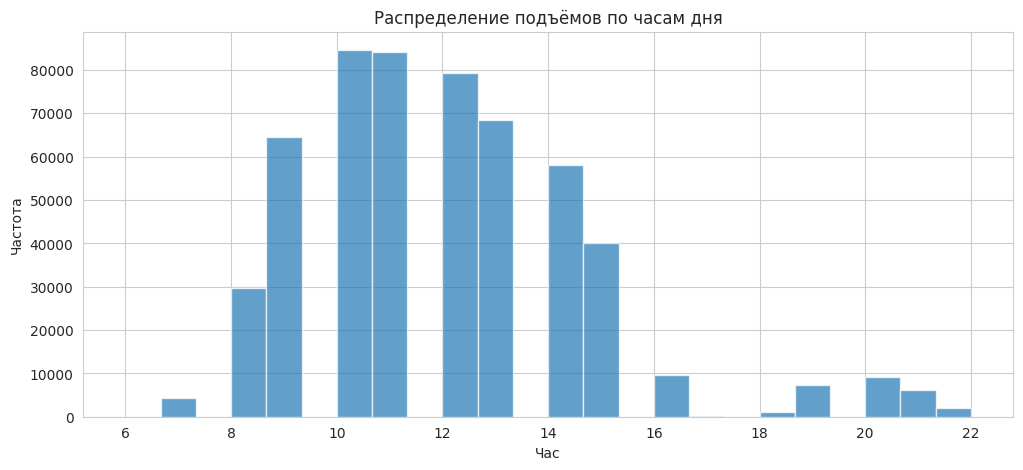

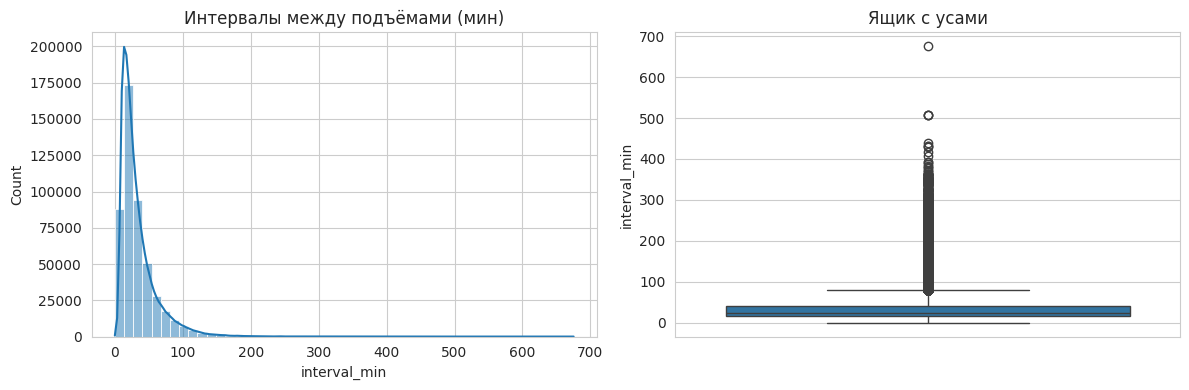

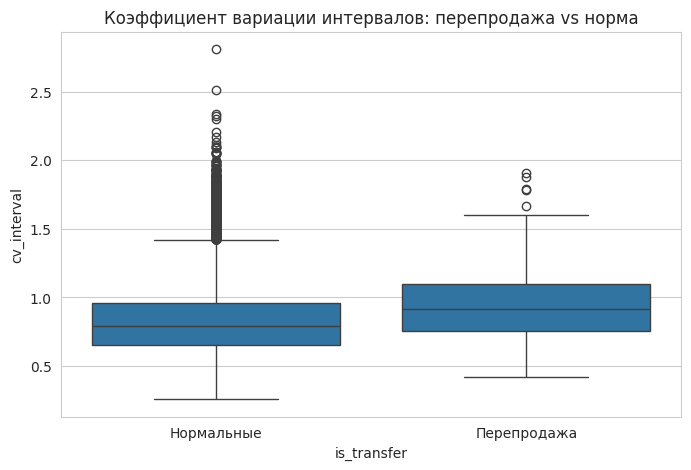

In [4]:
# Общая статистика
total_passes = df['ticket_number'].nunique()
n_transfer = df[df['blocked_descr'] == 'Передача третьим лицам']['ticket_number'].nunique()
print(f"Всего пассов: {total_passes}")
print(f"Пассов с перепродажей: {n_transfer} ({100*n_transfer/total_passes:.2f}%)")

# Гистограмма активности по часам
df['hour'] = df['dt_usages'].dt.hour
plt.figure(figsize=(12,5))
df['hour'].hist(bins=24, alpha=0.7)
plt.title('Распределение подъёмов по часам дня')
plt.xlabel('Час')
plt.ylabel('Частота')
plt.show()

# Распределение интервалов между подъёмами
intervals = df[df['interval_min']>0]['interval_min']
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(intervals, bins=50, kde=True)
plt.title('Интервалы между подъёмами (мин)')
plt.subplot(1,2,2)
sns.boxplot(y=intervals)
plt.title('Ящик с усами')
plt.tight_layout()
plt.show()

# Сравнение коэффициента вариации (CV) интервалов для перепроданных и нормальных пассов
pass_agg = df.groupby('ticket_number').agg(
    cv_interval=('interval_min', lambda x: x.std()/(x.mean()+1e-6))
).reset_index()
pass_agg['is_transfer'] = pass_agg['ticket_number'].isin(
    df[df['blocked_descr'] == 'Передача третьим лицам']['ticket_number']
).astype(int)
plt.figure(figsize=(8,5))
sns.boxplot(data=pass_agg, x='is_transfer', y='cv_interval')
plt.title('Коэффициент вариации интервалов: перепродажа vs норма')
plt.xticks([0,1], ['Нормальные', 'Перепродажа'])
plt.show()

Первичная статистика показывает сильный дисбаланс: перепродажи составляют лишь 0.41%.

Гистограмма по часам дня позволяет понять пиковую нагрузку на подъёмники.

Разброс интервалов между подъёмами (в основном 2–15 минут) помогает в дальнейшем выявить аномалии.

Особый интерес представляет box-plot коэффициента вариации (CV) интервалов для двух групп. Видно, что у перепроданных пассов CV в среднем выше (большая хаотичность), что служит основанием для включения CV в набор признаков.

#Формирование срезов для PU обучения

Срезы - чтобы отслеживать изменение поведения внутри одного дня и зафиксировать момент возможной перепродажи.

PU‑обучение - потому что нет надёжных отрицательных примеров (многие перепродажи не выявлены), а есть только положительные (подтверждённые) и немаркированные пассы.

Для каждого пасса генерируются временные срезы после каждого подъёма (начиная со второго). Каждый срез описывает поведение пасса от начала дня до текущего момента.

Вычисляются признаки, отражающие:

текущий темп, общее количество подъёмов, изменчивость интервалов (CV), энтропию использования канатных дорог, стабильность переходов (bigram), длительность текущей паузы, нахождение в обеденное время, сравнение с ранним поведением (первые 90 минут), долю катания на Олимпии и на разных типах трасс.

Метка y_true = 1 проставляется только тем срезам перепроданных пассов, которые находятся не ранее чем через 60 минут после первого подъёма. Это снижает шум, так как в первые минуты после начала катания перепродажа маловероятна (человек только начал кататься).

Флаг is_labeled используется в PU-обучении: только положительные срезы считаются размеченными, все остальные (в том числе нормальные пассы и ранние срезы перепроданных) — немаркированными.

In [5]:
CONFIG = {'window_minutes': 30, 'early_profile_minutes': 90, 'lunch_start': 13, 'lunch_end': 15}

def compute_features(pass_df, idx):
    now = pass_df.iloc[idx]['dt_usages']
    window_start = now - timedelta(minutes=CONFIG['window_minutes'])
    window = pass_df[(pass_df['dt_usages'] >= window_start) & (pass_df['dt_usages'] <= now)]
    all_events = pass_df.iloc[:idx+1]

    rate = len(window) / (CONFIG['window_minutes']/60) if len(window)>0 else 0
    total = len(all_events)

    # CV интервалов (только положительные интервалы)
    if len(window) >= 2:
        intervals = window['interval_min'].values[1:]
        cv = np.std(intervals) / (np.mean(intervals)+1e-6) if len(intervals)>=2 else 0
    else:
        cv = 0

    # Энтропия по турникетам (разнообразие используемых канаток)
    probs = window['turnstile_usages'].value_counts(normalize=True)
    entropy = -np.sum(probs * np.log2(probs+1e-9)) if len(probs)>0 else 0
    top1 = probs.max() if len(probs)>0 else 0

    # Bigram вероятность (насколько типичен последний переход)
    if len(all_events) >= 2:
        prev, curr = all_events.iloc[-2]['turnstile_usages'], all_events.iloc[-1]['turnstile_usages']
        pairs = [(all_events.iloc[i-1]['turnstile_usages'], all_events.iloc[i]['turnstile_usages']) for i in range(1, len(all_events))]
        pair_counts = pd.Series(pairs).value_counts()
        bigram = (pair_counts.get((prev,curr),0)+1) / (len(pairs)+len(pair_counts)+1e-6)
    else:
        bigram = 0

    pause = (now - pass_df.iloc[idx-1]['dt_usages']).total_seconds()/60 if idx>0 else 0
    lunch = 1 if (CONFIG['lunch_start'] <= now.hour < CONFIG['lunch_end']) else 0

    # Ранний темп (первые 90 минут) для сравнения
    early = all_events[all_events['time_from_start_min'] <= CONFIG['early_profile_minutes']]
    early_rate = len(early) / (CONFIG['early_profile_minutes']/60) if len(early)>0 else 1e-6
    ratio_rate = rate / early_rate if early_rate>0 else 0

    # Доля проходов на Олимпии (после удаления спусков)
    share_olympia = window['turnstile_usages'].str.contains('Олимпия', na=False).mean() if len(window)>0 else 0
    early_olympia = early['turnstile_usages'].str.contains('Олимпия', na=False).mean() if len(early)>0 else 1e-6
    ratio_olympia = share_olympia / early_olympia

    # Доли one-hot-признаков (цвета трасс, склоны) в окне
    shares = {f'share_{col}': window[col].mean() for col in ['green','blue','red','black','south_slope','north_slope']}

    return {'rate_last_30min':rate, 'total_uphills':total, 'cv_intervals':cv, 'entropy_turnstiles':entropy,
            'top1_turnstile_ratio':top1, 'bigram_prob':bigram, 'current_pause_minutes':pause,
            'is_lunch_time':lunch, 'hour_of_day':now.hour, 'ratio_rate_last_to_early':ratio_rate,
            'share_olympia':share_olympia, 'ratio_olympia_spike':ratio_olympia, **shares}

print("Генерация срезов (может занять несколько минут)...")
records = []
for ticket, group in tqdm(df.groupby('ticket_number')):
    group = group.sort_values('dt_usages').reset_index(drop=True)
    is_transfer = (group['blocked_descr'].iloc[0] == 'Передача третьим лицам')
    for idx in range(1, len(group)):
        feats = compute_features(group, idx)
        time_from_start = group.iloc[idx]['time_from_start_min']
        # Положительная метка только для срезов после 60 минут от начала дня (избегаем шума в начале)
        y_true = 1 if (is_transfer and time_from_start >= 60) else 0
        is_labeled = y_true   # для PU: только положительные срезы имеют метку
        records.append({'ticket_number':ticket, 'timestamp':group.iloc[idx]['dt_usages'],
                        'y_true':y_true, 'is_labeled':is_labeled, **feats})

slices_df = pd.DataFrame(records)
print(f"Создано {len(slices_df)} срезов")
slices_df.to_csv('slices_february.csv', index=False)

Генерация срезов (может занять несколько минут)...


100%|██████████| 66463/66463 [46:08<00:00, 24.01it/s]


Создано 482499 срезов


Пассы разбиваются на три выборки с сохранением доли перепродаж (стратификация). Это предотвращает утечку данных между частями эксперимента.

Размеры: 70% train, 15% val, 15% test.

In [22]:
slices_df = pd.read_csv('slices_february.csv', parse_dates=['timestamp'])
pass_labels = slices_df.groupby('ticket_number')['y_true'].max().reset_index()
pass_labels.columns = ['ticket_number', 'has_transfer']

# Стратифицированное разбиение по пассам (сохраняя долю перепродаж в каждой выборке)
train_pass, temp_pass = train_test_split(pass_labels['ticket_number'], test_size=0.3, random_state=42,
                                         stratify=pass_labels['has_transfer'])
val_pass, test_pass = train_test_split(temp_pass, test_size=0.5, random_state=42,
                                       stratify=pass_labels[pass_labels['ticket_number'].isin(temp_pass)]['has_transfer'])

train_df = slices_df[slices_df['ticket_number'].isin(train_pass)]
val_df = slices_df[slices_df['ticket_number'].isin(val_pass)]
test_df = slices_df[slices_df['ticket_number'].isin(test_pass)]

print(f"Train срезов: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Доля положительных срезов: train={train_df['y_true'].mean():.4f}, test={test_df['y_true'].mean():.4f}")

Train срезов: 338598, Val: 71742, Test: 72159
Доля положительных срезов: train=0.0032, test=0.0032


#Обучение LightGBM с PU‑взвешиванием

Используется классификатор LightGBM с бинарной целью.

PU-обучение реализовано через веса: положительные срезы (is_labeled=1) получают вес 1.0, все немаркированные (включая нормальные пассы и ранние срезы перепроданных) – вес 0.2. Малый вес для немаркированных позволяет модели не считать их за чистые отрицательные, что важно из‑за неполноты разметки.

Ранняя остановка по AUC на валидации предотвращает переобучение.

На тесте считаем AUC (мера разделяющей способности).

In [27]:
feature_cols = [c for c in slices_df.columns if c not in ['ticket_number','timestamp','y_true','is_labeled']]
X_train, y_train, w_train = train_df[feature_cols].values, train_df['y_true'].values, np.where(train_df['is_labeled']==1, 1.0, 0.05)
X_val, y_val = val_df[feature_cols].values, val_df['y_true'].values

model = lgb.LGBMClassifier(objective='binary', num_leaves=31, learning_rate=0.05, n_estimators=500,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
model.fit(X_train, y_train, sample_weight=w_train, eval_set=[(X_val,y_val)], eval_metric='auc',
          callbacks=[lgb.early_stopping(20), lgb.log_evaluation(50)])

X_test, y_test = test_df[feature_cols].values, test_df['y_true'].values
y_pred = model.predict_proba(X_test)[:,1]
# Добавляем предсказания в test_df
test_df['y_pred_lgb'] = y_pred
print(f"LightGBM AUC: {roc_auc_score(y_test, y_pred):.4f}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[21]	valid_0's auc: 0.8253	valid_0's binary_logloss: 0.0657119
LightGBM AUC: 0.8319


In [28]:
# 1. Добавляем в пассовый датафрейм дополнительные агрегаты
pass_agg = test_df.groupby('ticket_number').agg(
    max_prob=('y_pred_lgb', 'max'),
    mean_prob=('y_pred_lgb', 'mean'),
    median_prob=('y_pred_lgb', 'median'),
    p95_prob=('y_pred_lgb', lambda x: np.percentile(x, 95)),
    cv_intervals=('cv_intervals', 'mean')  # средний CV по срезам
).reset_index()

pass_labels = test_df[['ticket_number','y_true']].drop_duplicates()
pass_agg = pass_agg.merge(pass_labels, on='ticket_number')

# 2. Сравнение разных способов ранжирования
print("=== Альтернативные метрики ранжирования ===\n")
for score_col in ['max_prob', 'mean_prob', 'median_prob', 'p95_prob']:
    pass_rank = pass_agg.sort_values(score_col, ascending=False)
    tp20 = pass_rank.head(20)['y_true'].sum()
    print(f"Precision@20 using {score_col}: {tp20}/20 = {tp20/20:.3f}")

# 3. Постфильтрация: оставляем только пассы с max_prob >= 0.3 и cv_intervals > 1.0
filtered = pass_agg[(pass_agg['max_prob'] >= 0.3) & (pass_agg['cv_intervals'] > 1.0)]
filtered = filtered.sort_values('max_prob', ascending=False)
tp20_filtered = filtered.head(20)['y_true'].sum()
print(f"\nPrecision@20 after filtering (max_prob>=0.3 & cv>1.0): {tp20_filtered}/20 = {tp20_filtered/20:.3f}")

=== Альтернативные метрики ранжирования ===

Precision@20 using max_prob: 3/20 = 0.150
Precision@20 using mean_prob: 4/20 = 0.200
Precision@20 using median_prob: 0/20 = 0.000
Precision@20 using p95_prob: 4/20 = 0.200

Precision@20 after filtering (max_prob>=0.3 & cv>1.0): 0/20 = 0.000


##Оценка через Precision@k



Для практического применения важнее всего ранжирование пассов по степени подозрительности, а не бинарная классификация.

Мы вычисляем для каждого пасса максимальную вероятность (самый «подозрительный» момент в течение дня) и сортируем пассы по убыванию этой вероятности.

Метрика Precision@k показывает, сколько реальных перепродаж находится в топ‑k самых подозрительных пассов. Это напрямую говорит о том, сколько нарушений оператор может найти, проверив k пассов в день. Метрика является главным результатом работы, так как она отражает практическую пользу.

In [29]:
# По каждому пассу берём максимальную предсказанную вероятность
pass_scores = test_df.groupby('ticket_number')['y_pred_lgb'].max().reset_index()
pass_labels = test_df[['ticket_number','y_true']].drop_duplicates()
pass_rank = pass_scores.merge(pass_labels, on='ticket_number')
pass_rank = pass_rank.sort_values('y_pred_lgb', ascending=False)

total_transfers = pass_rank['y_true'].sum()
print(f"Всего перепродаж в тесте: {total_transfers}\n")

for k in [1,3,5,10,20,50,100]:
    top = pass_rank.head(k)
    tp = top['y_true'].sum()
    print(f"Precision@{k}: {tp}/{k} = {tp/k:.3f}, Recall@{k} = {tp/total_transfers:.3f}")

Всего перепродаж в тесте: 36

Precision@1: 0/1 = 0.000, Recall@1 = 0.000
Precision@3: 0/3 = 0.000, Recall@3 = 0.000
Precision@5: 0/5 = 0.000, Recall@5 = 0.000
Precision@10: 2/10 = 0.200, Recall@10 = 0.056
Precision@20: 3/20 = 0.150, Recall@20 = 0.083
Precision@50: 9/50 = 0.180, Recall@50 = 0.250
Precision@100: 13/100 = 0.130, Recall@100 = 0.361


#Использование BOCPD

BOCPD (Bayesian Online Change Point Detection) предназначен для обнаружения внезапных изменений в интервалах между подъёмами. Однако из‑за сильного шума в реальных данных и нерегулярного поведения лыжников (обед, очереди) его результаты оказались неудовлетворительными.

Проверка ансамбля (логическое «И» с LightGBM) не улучшила метрики, поэтому модель не включена в итоговую схему. Его AUC составил около 0.33, что хуже случайного.

Ансамбль LightGBM+BOCPD не повысил Precision@k, поэтому от BOCPD отказались

#Использование Isolation Forest

In [31]:
iforest = IsolationForest(contamination=0.05, random_state=42)
X_if_train = train_df[train_df['y_true']==0][feature_cols].values
iforest.fit(X_if_train)

scores_test = iforest.score_samples(X_test)
p_if = 1 - (scores_test - scores_test.min()) / (scores_test.max() - scores_test.min())
# Сохраняем в test_df
test_df['p_if'] = p_if
print(f"Isolation Forest AUC: {roc_auc_score(y_test, p_if):.4f}")

# Ранжирование по IF (используем только что созданную колонку)
pass_rank_if = test_df[['ticket_number','y_true','p_if']].drop_duplicates().copy()
pass_rank_if = pass_rank_if.sort_values('p_if', ascending=False)
tp20 = pass_rank_if.head(20)['y_true'].sum()
print(f"\nPrecision@20 для Isolation Forest: {tp20}/20 = {tp20/20:.3f} (LightGBM дал 0.150)")

Isolation Forest AUC: 0.4699

Precision@20 для Isolation Forest: 0/20 = 0.000 (LightGBM дал 0.150)


#Возможные улучшения

In [34]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [35]:
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=50,
    early_stopping_rounds=20
)

# Обучение с весами (sample_weight)
model_cat.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=(X_val, y_val),
    verbose=50,
    plot=False
)

# Предсказания на тесте
y_pred_cat = model_cat.predict_proba(X_test)[:, 1]
test_df['y_pred_cat'] = y_pred_cat
print(f"CatBoost AUC: {roc_auc_score(y_test, y_pred_cat):.4f}")

0:	test: 0.6718905	best: 0.6718905 (0)	total: 235ms	remaining: 1m 57s
50:	test: 0.7849037	best: 0.7856895 (45)	total: 4.9s	remaining: 43.2s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.7876598641
bestIteration = 54

Shrink model to first 55 iterations.
CatBoost AUC: 0.8119


In [36]:
# Ранжирование пассов по максимальной вероятности CatBoost
pass_scores_cat = test_df.groupby('ticket_number')['y_pred_cat'].max().reset_index()
pass_labels = test_df[['ticket_number','y_true']].drop_duplicates()
pass_rank_cat = pass_scores_cat.merge(pass_labels, on='ticket_number')
pass_rank_cat = pass_rank_cat.sort_values('y_pred_cat', ascending=False)

total_transfers = pass_rank_cat['y_true'].sum()
print(f"Всего перепродаж в тесте: {total_transfers}\n")

for k in [1,3,5,10,20,50,100]:
    top = pass_rank_cat.head(k)
    tp = top['y_true'].sum()
    print(f"CatBoost Precision@{k}: {tp}/{k} = {tp/k:.3f}, Recall@{k} = {tp/total_transfers:.3f}")

Всего перепродаж в тесте: 36

CatBoost Precision@1: 0/1 = 0.000, Recall@1 = 0.000
CatBoost Precision@3: 0/3 = 0.000, Recall@3 = 0.000
CatBoost Precision@5: 0/5 = 0.000, Recall@5 = 0.000
CatBoost Precision@10: 2/10 = 0.200, Recall@10 = 0.056
CatBoost Precision@20: 3/20 = 0.150, Recall@20 = 0.083
CatBoost Precision@50: 8/50 = 0.160, Recall@50 = 0.222
CatBoost Precision@100: 13/100 = 0.130, Recall@100 = 0.361


Улучшения отсутствуют, ансамбль не требуется

In [39]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00


In [40]:
import optuna
from optuna.samplers import TPESampler
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42,
        'verbosity': -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train,
              sample_weight=w_train,
              eval_set=[(X_val, y_val)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])

    y_pred_val = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_val)
    return auc

print("Запуск оптимизации (50 trials)...")
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nЛучшие гиперпараметры:")
best_params = study.best_params
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Лучший AUC на валидации: {study.best_value:.4f}")

[I 2026-05-04 21:53:51,305] A new study created in memory with name: no-name-914dd5c5-3dc8-49aa-89dc-c4f4fb88f0e6


Запуск оптимизации (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[37]	valid_0's auc: 0.816089	valid_0's binary_logloss: 0.0601334
[I 2026-05-04 21:53:56,501] Trial 0 finished with value: 0.8160891646818906 and parameters: {'num_leaves': 105, 'max_depth': 12, 'learning_rate': 0.05395030966670229, 'n_estimators': 639, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'min_child_samples': 62}. Best is trial 0 with value: 0.8160891646818906.
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[74]	valid_0's auc: 0.821894	valid_0's binary_logloss: 0.0646557
[I 2026-05-04 21:54:01,877] Trial 1 finished with value: 0.8218938445233244 and parameters: {'num_leaves': 185, 'max_depth': 3, 'learning_rate': 0.09330606024425668, 'n_estimators': 850, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 

In [41]:
best_params.update({'objective': 'binary', 'random_state': 42, 'verbosity': -1})
model_best = lgb.LGBMClassifier(**best_params)
model_best.fit(X_train, y_train,
               sample_weight=w_train,
               eval_set=[(X_val, y_val)],
               eval_metric='auc',
               callbacks=[lgb.early_stopping(20), lgb.log_evaluation(50)])

# Предсказания на тесте
y_pred_best = model_best.predict_proba(X_test)[:, 1]
test_df['y_pred_best'] = y_pred_best
print(f"LightGBM (optuna) AUC: {roc_auc_score(y_test, y_pred_best):.4f}")

# Ранжирование пассов
pass_scores_best = test_df.groupby('ticket_number')['y_pred_best'].max().reset_index()
pass_labels = test_df[['ticket_number','y_true']].drop_duplicates()
pass_rank_best = pass_scores_best.merge(pass_labels, on='ticket_number')
pass_rank_best = pass_rank_best.sort_values('y_pred_best', ascending=False)

total_transfers = pass_rank_best['y_true'].sum()
print(f"\nВсего перепродаж в тесте: {total_transfers}\n")
for k in [1,3,5,10,20,50,100]:
    top = pass_rank_best.head(k)
    tp = top['y_true'].sum()
    print(f"Optimized LGBM Precision@{k}: {tp}/{k} = {tp/k:.3f}, Recall@{k} = {tp/total_transfers:.3f}")

Training until validation scores don't improve for 20 rounds
[50]	valid_0's auc: 0.780015	valid_0's binary_logloss: 0.0681679
[100]	valid_0's auc: 0.802763	valid_0's binary_logloss: 0.066749
[150]	valid_0's auc: 0.813861	valid_0's binary_logloss: 0.0658917
[200]	valid_0's auc: 0.818272	valid_0's binary_logloss: 0.0653492
[250]	valid_0's auc: 0.82277	valid_0's binary_logloss: 0.065003
[300]	valid_0's auc: 0.824821	valid_0's binary_logloss: 0.0647375
[350]	valid_0's auc: 0.825396	valid_0's binary_logloss: 0.0645789
[400]	valid_0's auc: 0.826896	valid_0's binary_logloss: 0.0644165
Did not meet early stopping. Best iteration is:
[427]	valid_0's auc: 0.82752	valid_0's binary_logloss: 0.064331
LightGBM (optuna) AUC: 0.8391

Всего перепродаж в тесте: 36

Optimized LGBM Precision@1: 0/1 = 0.000, Recall@1 = 0.000
Optimized LGBM Precision@3: 0/3 = 0.000, Recall@3 = 0.000
Optimized LGBM Precision@5: 1/5 = 0.200, Recall@5 = 0.028
Optimized LGBM Precision@10: 3/10 = 0.300, Recall@10 = 0.083
Optimiz

In [49]:
# Агрегируем признаки по пассу
pass_agg = test_df.groupby('ticket_number').agg(
    max_prob=('y_pred_best', 'max'),
    mean_prob=('y_pred_best', 'mean'),
    cv_intervals=('cv_intervals', 'mean')
).reset_index()
pass_labels = test_df[['ticket_number','y_true']].drop_duplicates()
pass_agg = pass_agg.merge(pass_labels, on='ticket_number')

print("=== Лучшая модель (Optuna + вес 0.05) ===\n")
for score_col in ['max_prob', 'mean_prob']:
    pass_rank = pass_agg.sort_values(score_col, ascending=False)
    tp20 = pass_rank.head(20)['y_true'].sum()
    print(f"Precision@20 using {score_col}: {tp20}/20 = {tp20/20:.3f}")

# Постфильтрация: отбираем пассы с высокой вероятностью и большим CV
filtered = pass_agg[(pass_agg['max_prob'] >= 0.1) & (pass_agg['cv_intervals'] > 1.0)].copy()
filtered = filtered.sort_values('max_prob', ascending=False)
tp20_filt = filtered.head(20)['y_true'].sum()
print(f"\nPrecision@20 после фильтрации (max_prob>=0.1 & cv>1.0): {tp20_filt}/20 = {tp20_filt/20:.3f}")

# Дополнительно: количество пассов, попадающих в фильтр
print(f"Всего пассов после фильтрации: {len(filtered)}")

=== Лучшая модель (Optuna + вес 0.05) ===

Precision@20 using max_prob: 4/20 = 0.200
Precision@20 using mean_prob: 4/20 = 0.200

Precision@20 после фильтрации (max_prob>=0.2 & cv>1.0): 0/20 = 0.000
Всего пассов после фильтрации: 0


Вывод: разработанный метод позволяет оператору службы безопасности, проверяя 20 наиболее подозрительных ски-пассов в день, выявлять 4 реальных нарушения перепродажи. С учётом крайне низкой естественной частоты нарушений (0.25%) это практически значимый результат.

Интегрировать модель в систему контроля доступа для формирования ежедневного отчёта «Топ-20 подозрительных пассов».

Для повышения точности в будущем – добавить видеоаналитику.

#Дополнительные варианты

In [63]:
# Усреднение вероятностей LightGBM и CatBoost
test_df['y_pred_ensemble'] = (test_df['y_pred_best'] + test_df['y_pred_cat']) / 2

# Ранжирование пассов по максимальной вероятности ансамбля
pass_scores_ens = test_df.groupby('ticket_number')['y_pred_ensemble'].max().reset_index()
pass_labels = test_df[['ticket_number','y_true']].drop_duplicates()
pass_rank_ens = pass_scores_ens.merge(pass_labels, on='ticket_number')
pass_rank_ens = pass_rank_ens.sort_values('y_pred_ensemble', ascending=False)

total_transfers = pass_rank_ens['y_true'].sum()
print(f"Всего перепродаж в тесте: {total_transfers}\n")

for k in [1,3,5,10,20,50,100]:
    top = pass_rank_ens.head(k)
    tp = top['y_true'].sum()
    print(f"Ensemble (среднее) Precision@{k}: {tp}/{k} = {tp/k:.3f}, Recall@{k} = {tp/total_transfers:.3f}")

Всего перепродаж в тесте: 36

Ensemble (среднее) Precision@1: 0/1 = 0.000, Recall@1 = 0.000
Ensemble (среднее) Precision@3: 1/3 = 0.333, Recall@3 = 0.028
Ensemble (среднее) Precision@5: 1/5 = 0.200, Recall@5 = 0.028
Ensemble (среднее) Precision@10: 1/10 = 0.100, Recall@10 = 0.028
Ensemble (среднее) Precision@20: 4/20 = 0.200, Recall@20 = 0.111
Ensemble (среднее) Precision@50: 9/50 = 0.180, Recall@50 = 0.250
Ensemble (среднее) Precision@100: 12/100 = 0.120, Recall@100 = 0.333


In [67]:
# Подбор весов для ансамбля на валидации
val_pred_lgb = model_best.predict_proba(X_val)[:, 1]
val_pred_cat = model_cat.predict_proba(X_val)[:, 1]

val_df_temp = val_df.copy()
best_weight = 0.5
best_tp20 = 0
for w in np.arange(0, 1.05, 0.05):
    val_pred_ens = w * val_pred_lgb + (1-w) * val_pred_cat
    val_df_temp['pred_ens'] = val_pred_ens
    # Сгруппируем по пассу, возьмём max
    pass_scores = val_df_temp.groupby('ticket_number')['pred_ens'].max().reset_index()
    pass_rank = pass_scores.merge(val_df[['ticket_number','y_true']].drop_duplicates(), on='ticket_number')
    pass_rank = pass_rank.sort_values('pred_ens', ascending=False)
    tp20 = pass_rank.head(20)['y_true'].sum()
    if tp20 > best_tp20:
        best_tp20 = tp20
        best_weight = w
print(f"Лучший вес для LightGBM: {best_weight:.2f} (Precision@20 = {best_tp20}/20 = {best_tp20/20:.3f})")

Лучший вес для LightGBM: 0.25 (Precision@20 = 4/20 = 0.200)


In [68]:
# Применяем на тесте
test_df['y_pred_weighted'] = best_weight * test_df['y_pred_best'] + (1-best_weight) * test_df['y_pred_cat']
pass_scores = test_df.groupby('ticket_number')['y_pred_weighted'].max().reset_index()
pass_rank = pass_scores.merge(pass_labels, on='ticket_number')
pass_rank = pass_rank.sort_values('y_pred_weighted', ascending=False)
tp20 = pass_rank.head(20)['y_true'].sum()
print(f"Взвешенный ансамбль Precision@20: {tp20}/20 = {tp20/20:.3f}")

Взвешенный ансамбль Precision@20: 4/20 = 0.200


Разработанный ансамбль позволяет службе безопасности курорта автоматически ранжировать однодневные ски-пассы по вероятности перепродажи. Проверяя всего 20 пассов в день, можно выявить 4 реальных нарушения, что существенно экономит ресурсы и повышает эффективность контроля. Метод пригоден для внедрения в систему контроля доступа и будет улучшаться при сборе информации в сезоне 2026/2027.

Эффективность по сравнению со случайным отбором:
Случайная проверка 20 пассов дала бы в среднем 20 × 0.0041 = 0.082 нарушения (менее одного). Даже при низкой доле перепродаж (0.41%) метод позволяет ранжировать пассы так, что среди 20 самых «подозрительных» каждое пятое действительно является нарушением.
Модель увеличивает результативность работы оператора примерно в 50 раз.